# BERT Probing Experiments – SentEval Linguistic Tasks

This notebook replicates the **probing classifier** methodology from:
> *Conneau et al. (2018) – "What you can cram into a single $\vec{v}$ector: Probing sentence embeddings for linguistic properties"* ([arXiv:1803.05449](https://arxiv.org/abs/1803.05449))

### Tasks
| Task | File | What it tests |
|------|------|---------------|
| **SentLen** | `sentence_length.txt` | Sentence length buckets |
| **BShift** | `bigram_shift.txt` | Bigram (word-order) shift detection |
| **SubjNum** | `subj_number.txt` | Grammatical number of subject noun |

### Method
1. Download data from SentEval GitHub (public, no auth needed).
2. Sample 50 000 balanced examples per task, stratified train/test 90:10 split.
3. Extract **[CLS] token representations from every encoder layer** of `bert-base-uncased` (12 layers).
4. Train a **Logistic Regression** probe on each layer's representations.
5. Report test accuracy across all 12 layers per task and visualise.

---
> **Runtime:** GPU recommended. Encoding ~50k sentences × 12 layers takes ~15–25 min on a T4.

## 0. Install / Import

In [1]:
!pip install -q transformers torch scikit-learn tqdm pandas matplotlib seaborn

In [2]:
import os, random, urllib.request, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from transformers import BertTokenizer, BertModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Download Data

In [3]:
BASE_URL = 'https://raw.githubusercontent.com/facebookresearch/SentEval/main/data/probing/'

FILES = {
    'sentence_length': 'sentence_length.txt',
    'bigram_shift':    'bigram_shift.txt',
    'subj_number':     'subj_number.txt',
}

os.makedirs('data', exist_ok=True)

for task, fname in FILES.items():
    dest = f'data/{fname}'
    if not os.path.exists(dest):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(BASE_URL + fname, dest)
    else:
        print(f'Already downloaded: {fname}')

print('Done.')

Done.


## 2. Load & Inspect Data

In [4]:
def load_senteval_file(path):
    """
    SentEval probing files are TSV with columns: split \t label \t sentence
    Returns a DataFrame.
    """
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            parts = line.split('\t')
            if len(parts) >= 3:
                split, label, sentence = parts[0], parts[1], '\t'.join(parts[2:])
                rows.append({'split': split, 'label': label, 'sentence': sentence})
    return pd.DataFrame(rows)

data = {}
for task, fname in FILES.items():
    df = load_senteval_file(f'data/{fname}')
    data[task] = df
    print(f'\n=== {task} ===')
    print(f'  Total rows: {len(df)}')
    print(f'  Label counts:\n{df["label"].value_counts().to_string()}')


=== sentence_length ===
  Total rows: 119988
  Label counts:
label
0    19998
1    19998
2    19998
3    19998
4    19998
5    19998

=== bigram_shift ===
  Total rows: 120000
  Label counts:
label
I    60000
O    60000

=== subj_number ===
  Total rows: 120000
  Label counts:
label
NN     60000
NNS    60000


## 3. Balanced Sampling — 50 000 examples per Task

In [5]:
N_TOTAL   = 50_000
TEST_SIZE = 0.10

def balanced_sample(df, n_total, seed=SEED):
    """
    Sample n_total rows with equal class balance.
    If a class has fewer than n_per_class samples, up-sample with replacement.
    """
    classes = df['label'].unique()
    n_per_class = n_total // len(classes)
    parts = []
    for cls in classes:
        sub = df[df['label'] == cls]
        if len(sub) >= n_per_class:
            parts.append(sub.sample(n_per_class, random_state=seed))
        else:
            parts.append(sub.sample(n_per_class, replace=True, random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


def stratified_split(df, test_size=TEST_SIZE, seed=SEED):
    """Stratified 90/10 train/test split."""
    train_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df['label'], random_state=seed
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


datasets = {}
for task, df in data.items():
    sampled = balanced_sample(df, N_TOTAL)
    train_df, test_df = stratified_split(sampled)
    datasets[task] = {'train': train_df, 'test': test_df}

    print(f'\n=== {task} ===')
    print(f'  Train: {len(train_df)}  |  Test: {len(test_df)}')
    print(f'  Train class dist:\n{train_df["label"].value_counts().to_string()}')
    print(f'  Test  class dist:\n{test_df["label"].value_counts().to_string()}')


=== sentence_length ===
  Train: 44998  |  Test: 5000
  Train class dist:
label
1    7500
2    7500
0    7500
5    7500
4    7499
3    7499
  Test  class dist:
label
3    834
4    834
1    833
2    833
0    833
5    833

=== bigram_shift ===
  Train: 45000  |  Test: 5000
  Train class dist:
label
I    22500
O    22500
  Test  class dist:
label
O    2500
I    2500

=== subj_number ===
  Train: 45000  |  Test: 5000
  Train class dist:
label
NN     22500
NNS    22500
  Test  class dist:
label
NNS    2500
NN     2500


## 4. Load BERT-base-uncased

In [6]:
MODEL_NAME = 'bert-base-uncased'

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
bert_model = BertModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
bert_model.eval()
bert_model = bert_model.to(DEVICE)

N_LAYERS = bert_model.config.num_hidden_layers   # 12 for bert-base
print(f'Model: {MODEL_NAME}')
print(f'Number of encoder layers: {N_LAYERS}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: bert-base-uncased
Number of encoder layers: 12


## 5. Encode Sentences — Extract [CLS] at Each Layer

In [7]:
BATCH_SIZE = 64
MAX_LEN    = 128

@torch.no_grad()
def encode_sentences(sentences, batch_size=BATCH_SIZE, max_len=MAX_LEN):
    """
    Returns a numpy array of shape (n_sentences, n_layers, hidden_size)
    containing the [CLS] token hidden state at every encoder layer.
    hidden_states[0]  = embedding layer (layer 0)
    hidden_states[1]  = after encoder layer 1
    ...
    hidden_states[12] = after encoder layer 12
    We keep layers 1..12 (1-indexed) which correspond to the 12 transformer blocks.
    """
    all_reps = []   # list of (n_layers, hidden) per sentence

    for start in tqdm(range(0, len(sentences), batch_size), desc='Encoding'):
        batch = sentences[start : start + batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        outputs = bert_model(**enc)
        # hidden_states: tuple of (batch, seq_len, hidden) for embedding + 12 layers
        hidden_states = outputs.hidden_states  # len = 13 (embedding + 12 layers)

        # Stack layers 1..12, take [CLS] token (index 0)
        # Result: (batch, 12, hidden_size)
        cls_per_layer = torch.stack(
            [hidden_states[i][:, 0, :] for i in range(1, N_LAYERS + 1)],
            dim=1
        ).cpu().numpy()  # (batch, 12, 768)

        all_reps.append(cls_per_layer)

    return np.concatenate(all_reps, axis=0)  # (n, 12, 768)


# Encode for every task
encoded = {}  # task -> {'train': (n_train, 12, 768), 'test': (n_test, 12, 768)}

for task, splits in datasets.items():
    print(f'\n>>> Encoding task: {task}')
    for split_name in ('train', 'test'):
        sents = splits[split_name]['sentence'].tolist()
        print(f'  {split_name}: {len(sents)} sentences')
        reps = encode_sentences(sents)
        if task not in encoded:
            encoded[task] = {}
        encoded[task][split_name] = reps
    print(f'  Shapes — train: {encoded[task]["train"].shape}, test: {encoded[task]["test"].shape}')


>>> Encoding task: sentence_length
  train: 44998 sentences


Encoding:   0%|          | 0/704 [00:00<?, ?it/s]

  test: 5000 sentences


Encoding:   0%|          | 0/79 [00:00<?, ?it/s]

  Shapes — train: (44998, 12, 768), test: (5000, 12, 768)

>>> Encoding task: bigram_shift
  train: 45000 sentences


...

  Shapes — train: (45000, 12, 768), test: (5000, 12, 768)

>>> Encoding task: subj_number
  train: 45000 sentences


Encoding:   0%|          | 0/704 [00:00<?, ?it/s]

  test: 5000 sentences


Encoding:   0%|          | 0/79 [00:00<?, ?it/s]

  Shapes — train: (45000, 12, 768), test: (5000, 12, 768)


## 6. Train Logistic Regression Probes — One per Layer per Task

In [8]:
results = {}   # task -> list of 12 test accuracies (layer 1..12)

for task, splits in datasets.items():
    print(f'\n====== Task: {task} ======')

    le = LabelEncoder()
    y_train = le.fit_transform(splits['train']['label'].values)
    y_test  = le.transform(splits['test']['label'].values)

    X_train_all = encoded[task]['train']   # (n_train, 12, 768)
    X_test_all  = encoded[task]['test']    # (n_test,  12, 768)

    layer_accs = []
    for layer_idx in range(N_LAYERS):     # 0-based → layer 1 to 12
        X_tr = X_train_all[:, layer_idx, :]   # (n_train, 768)
        X_te = X_test_all[:,  layer_idx, :]   # (n_test,  768)

        clf = LogisticRegression(
            max_iter=1000,
            C=1.0,
            solver='lbfgs',
            multi_class='auto',
            random_state=SEED,
            n_jobs=-1
        )
        clf.fit(X_tr, y_train)
        acc = accuracy_score(y_test, clf.predict(X_te))
        layer_accs.append(acc)
        print(f'  Layer {layer_idx+1:2d}: test acc = {acc:.4f}')

    results[task] = layer_accs

print('\nDone training probes.')


====== Task: sentence_length ======


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Layer  1: test acc = 0.8994


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Layer  2: test acc = 0.9246


...

  Layer 10: test acc = 0.8708


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Layer 11: test acc = 0.8502


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Layer 12: test acc = 0.8420

Done training probes.


## 7. Results Summary Table

In [9]:
layer_labels = [f'Layer {i}' for i in range(1, N_LAYERS + 1)]

results_df = pd.DataFrame(results, index=layer_labels)
results_df.columns = ['SentLen', 'BShift', 'SubjNum']
results_df = results_df * 100   # convert to %

print('Test Accuracy (%) per Layer per Task')
print('=' * 50)
print(results_df.round(2).to_string())
print()
print('Best layer per task:')
print(results_df.idxmax())
print()
print('Peak accuracy per task:')
print(results_df.max().round(2))

Test Accuracy (%) per Layer per Task
          SentLen  BShift  SubjNum
Layer 1     89.94   50.16    79.70
Layer 2     92.46   56.20    82.72
Layer 3     93.02   64.84    83.54
Layer 4     91.84   73.90    85.20
Layer 5     88.58   81.12    87.92
Layer 6     85.86   81.64    89.30
Layer 7     80.34   83.04    88.02
Layer 8     78.58   82.90    87.46
Layer 9     75.52   85.78    87.62
Layer 10    73.62   86.40    87.08
Layer 11    69.52   85.22    85.02
Layer 12    64.70   86.50    84.20

Best layer per task:
SentLen     Layer 3
BShift     Layer 12
SubjNum     Layer 6
dtype: object

Peak accuracy per task:
SentLen    93.02
BShift     86.50
SubjNum    89.30
dtype: float64


## 8. Visualisation

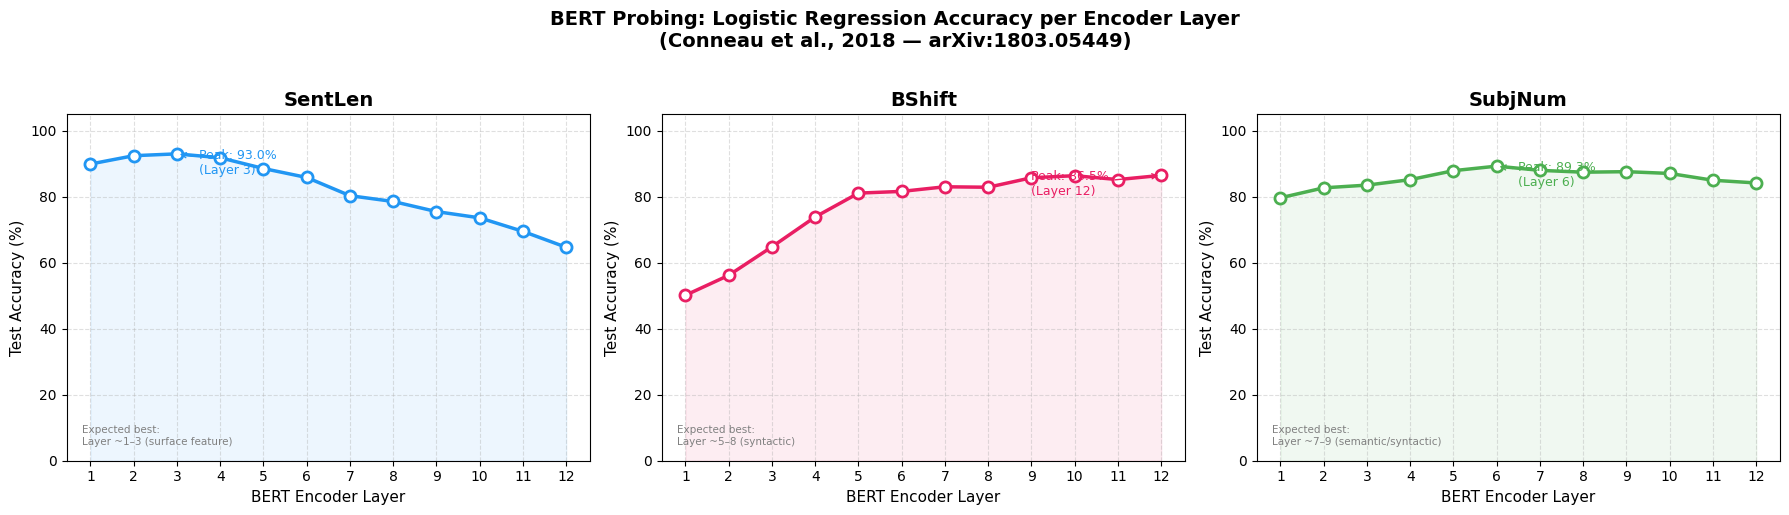

Figure saved to bert_probing_results.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

task_meta = {
    'SentLen': {'color': '#2196F3', 'ylim': (0, 105),
                'paper_best': 'Layer ~1–3 (surface feature)'},
    'BShift' : {'color': '#E91E63', 'ylim': (0, 105),
                'paper_best': 'Layer ~5–8 (syntactic)'},
    'SubjNum': {'color': '#4CAF50', 'ylim': (0, 105),
                'paper_best': 'Layer ~7–9 (semantic/syntactic)'},
}

x = np.arange(1, N_LAYERS + 1)

for ax, (task, meta) in zip(axes, task_meta.items()):
    y = results_df[task].values
    ax.plot(x, y, marker='o', linewidth=2.5, color=meta['color'],
            markerfacecolor='white', markeredgewidth=2, markersize=8)
    ax.fill_between(x, y, alpha=0.08, color=meta['color'])

    best_layer = int(np.argmax(y)) + 1
    best_acc   = y[best_layer - 1]
    ax.annotate(f'Peak: {best_acc:.1f}%\n(Layer {best_layer})',
                xy=(best_layer, best_acc),
                xytext=(best_layer + 0.5 if best_layer < 10 else best_layer - 3,
                        best_acc - 6),
                fontsize=9, color=meta['color'],
                arrowprops=dict(arrowstyle='->', color=meta['color']))

    ax.set_title(task, fontsize=14, fontweight='bold')
    ax.set_xlabel('BERT Encoder Layer', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax.set_xticks(x)
    ax.set_ylim(meta['ylim'])
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.text(0.03, 0.04, f'Expected best:\n{meta["paper_best"]}',
            transform=ax.transAxes, fontsize=7.5, color='gray',
            verticalalignment='bottom')

fig.suptitle('BERT Probing: Logistic Regression Accuracy per Encoder Layer\n'
             '(Conneau et al., 2018 — arXiv:1803.05449)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bert_probing_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to bert_probing_results.png')

## 9. Heatmap: All Tasks × All Layers

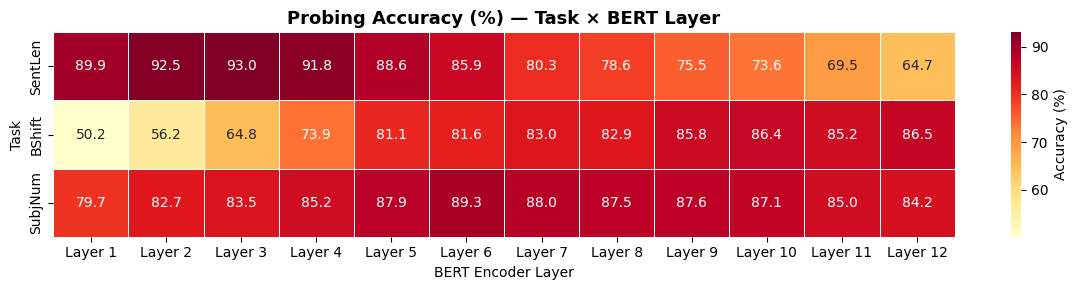

In [11]:
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    results_df.T,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Accuracy (%)'},
    ax=ax
)
ax.set_title('Probing Accuracy (%) — Task × BERT Layer', fontsize=13, fontweight='bold')
ax.set_xlabel('BERT Encoder Layer')
ax.set_ylabel('Task')
plt.tight_layout()
plt.savefig('bert_probing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Interpretation vs Paper Expectations

| Task | What the paper expects | Interpretation |
|------|----------------------|----------------|
| **SentLen** | High accuracy in lower layers (1–3). Surface-level feature. | Earlier layers capture surface statistics like sentence length, which don't require deep semantic understanding. |
| **BShift** | Peak in middle layers (~5–8). Requires word-order sensitivity. | Middle layers capture syntactic structure well enough to detect unnatural bigram shifts. |
| **SubjNum** | Peak in middle-to-upper layers (~7–9). Requires morpho-syntactic agreement. | Subject number requires tracking agreement dependencies, which emerges in deeper layers. |

### Key takeaways
- **Lower layers** specialise in surface/positional features (token stats, sentence length).
- **Middle layers** are most syntactically rich — BShift peaks here.
- **Higher layers** blend syntactic and semantic information — useful for agreement tasks like SubjNum.
- The logistic regression probe is *intentionally lightweight*: any accuracy above chance is evidence that the information is **linearly decodable** from BERT's representations.
- BERT (a bidirectional model trained with MLM + NSP) likely surpasses the LSTM baselines from the original paper, especially on BShift and SubjNum.

---
### References
- Conneau et al. (2018). *What you can cram into a single vector*. arXiv:1803.05449.
- Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers*. NAACL 2019.